# Conducción de calor transitoria en una placa de acero

**Proyecto de simulación — ICF130, Fundamentos de la Termodinámica**

**Autores:** Ignacio Díaz · Flavia Pedraza

---

Se estudia la evolución de la temperatura en una placa rectangular de acero, comparando la
**solución analítica** por separación de variables con un **solver numérico** de diferencias
finitas explícitas (FTCS), y se evalúa el efecto de una fuente de calor interna.

La ecuación de gobierno es la ecuación del calor en dos dimensiones con generación interna:

$$
\frac{\partial T}{\partial t} = \alpha\left(\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2}\right) + \frac{\dot{q}}{\rho c_p},
\qquad \alpha = \frac{k}{\rho c_p}
$$

**Condiciones de borde e inicial:**

| Frontera | Condición |
|---|---|
| $x = 0$ | Dirichlet, $T = 100$ °C |
| $x = L_x$ | Dirichlet, $T = 50$ °C |
| $y = 0$ y $y = L_y$ | Adiabática (Neumann homogénea), $\partial T/\partial y = 0$ |
| $t = 0$ | $T = 20$ °C uniforme |

## Parámetros y funciones base

Todas las constantes del material y las funciones compartidas se definen una sola vez aquí, y
el resto del notebook las reutiliza.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

# ---- Geometria y propiedades del acero ----
Lx, Ly = 0.5, 0.3            # m
k      = 45.0                # W/(m K)
rho    = 7800.0              # kg/m^3
cp     = 460.0               # J/(kg K)
alpha  = k / (rho * cp)      # m^2/s

# ---- Condiciones ----
T_izq, T_der = 100.0, 50.0   # C, Dirichlet en x = 0 y x = Lx
T_ini        = 20.0          # C, temperatura inicial uniforme

print(f"Difusividad termica alpha = {alpha:.4e} m^2/s")


# =========================  Solucion analitica  =========================

def T_steady(x):
    """Perfil estacionario: variacion lineal entre ambos bordes de Dirichlet."""
    return T_izq + (T_der - T_izq) * np.asarray(x, dtype=float) / Lx


def bn(n):
    """Coeficiente de Fourier n-esimo de la condicion inicial transitoria.

    La parte transitoria arranca en theta(x,0) = T_ini - T_ss(x), que es una funcion
    lineal A + B x. Su integral contra sin(n pi x / Lx) tiene forma cerrada, de modo
    que no hace falta cuadratura numerica (que ademas falla para n grande, porque el
    integrando oscila demasiado).
    """
    A = T_ini - T_izq
    B = (T_izq - T_der) / Lx
    s = (-1.0) ** n
    return (2.0 / (n * np.pi)) * (A * (1.0 - s) - B * s * Lx)


def T_analitica(x, t, n_terminos=50):
    """Temperatura analitica T(x, t), vectorizada en x.

    No depende de y: los bordes horizontales son adiabaticos y la condicion inicial es
    uniforme, de modo que el problema 2D se reduce exactamente al problema 1D en x.
    """
    x = np.asarray(x, dtype=float)
    val = T_steady(x)
    for n in range(1, n_terminos + 1):
        lam = n * np.pi / Lx
        val = val + bn(n) * np.sin(lam * x) * np.exp(-alpha * lam**2 * t)
    return val


# =====================  Solver numerico (FTCS explicito)  =====================

def malla(dx, dy):
    """Numero de nodos en cada direccion."""
    return int(round(Lx / dx)) + 1, int(round(Ly / dy)) + 1


def paso_estable(dx, dy, alpha_val=None, seguridad=0.9):
    """Paso temporal estable para FTCS en 2D.

    La condicion de estabilidad de von Neumann para el esquema explicito es

        alpha * dt * (1/dx^2 + 1/dy^2) <= 1/2

    El limite es 1/2, no 1: cada direccion aporta su propio termino y el peor modo
    de Fourier los suma. Se aplica un margen de seguridad del 10%.
    """
    a = alpha if alpha_val is None else alpha_val
    return seguridad * 0.5 / (a * (1.0 / dx**2 + 1.0 / dy**2))


def solver_ftcs(t_final, dx=0.01, dy=0.01, q0=0.0, alpha_val=None, dt=None,
                tiempos=(), sonda=None):
    """Integra la ecuacion del calor 2D con diferencias finitas explicitas.

    Los bordes en x son Dirichlet y los bordes en y adiabaticos (nodo espejo). El
    ultimo sub-paso se recorta para caer exactamente sobre cada tiempo pedido, de modo
    que las instantaneas corresponden al tiempo solicitado y no a uno aproximado.

    Devuelve un diccionario con el campo final, las instantaneas, el historial de la
    sonda y el paso temporal empleado.
    """
    a = alpha if alpha_val is None else alpha_val
    if dt is None:
        dt = paso_estable(dx, dy, a)

    Nx, Ny = malla(dx, dy)
    T = np.full((Ny, Nx), T_ini)

    def aplicar_bordes():
        T[:, 0], T[:, -1] = T_izq, T_der
        T[0, :], T[-1, :] = T[1, :], T[-2, :]

    snapshots = {}
    t_hist, T_hist = [], []
    t = 0.0

    aplicar_bordes()
    if sonda is not None:
        t_hist.append(t)
        T_hist.append(T[sonda[0], sonda[1]])

    for objetivo in sorted(set(list(tiempos) + [t_final])):
        while t < objetivo - 1e-12:
            paso = min(dt, objetivo - t)
            cx = a * paso / dx**2
            cy = a * paso / dy**2
            fuente = (q0 / (rho * cp)) * paso

            d2Tx = T[1:-1, 2:] - 2 * T[1:-1, 1:-1] + T[1:-1, :-2]
            d2Ty = T[2:, 1:-1] - 2 * T[1:-1, 1:-1] + T[:-2, 1:-1]
            T[1:-1, 1:-1] += cx * d2Tx + cy * d2Ty + fuente

            t += paso
            aplicar_bordes()
            if sonda is not None:
                t_hist.append(t)
                T_hist.append(T[sonda[0], sonda[1]])
        snapshots[objetivo] = T.copy()

    return {"T": T, "snapshots": snapshots, "dt": dt,
            "t_sonda": np.array(t_hist), "T_sonda": np.array(T_hist)}

Difusividad termica alpha = 1.2542e-05 m^2/s


## Esquema del dominio

Diagrama del dominio computacional con sus condiciones de borde.

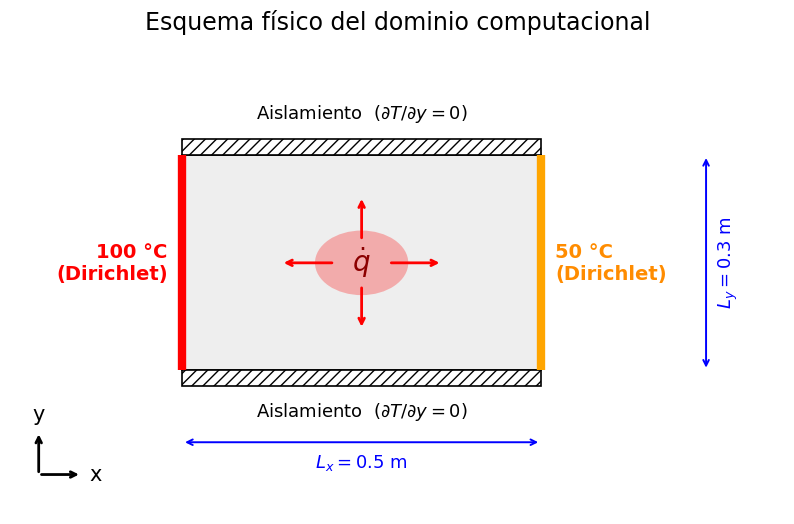

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

# Placa
ax.add_patch(patches.Rectangle((0, 0), Lx, Ly, facecolor="#eeeeee", edgecolor="black", lw=1.2))

# Bordes aislados (arriba y abajo), con achurado
espesor = 0.022
for y0 in (Ly, -espesor):
    ax.add_patch(patches.Rectangle((0, y0), Lx, espesor, facecolor="white",
                                   edgecolor="black", hatch="///", lw=1.2))

# Bordes de Dirichlet
ax.plot([0, 0], [0, Ly], color="red", lw=6, solid_capstyle="butt")
ax.plot([Lx, Lx], [0, Ly], color="orange", lw=6, solid_capstyle="butt")

# Fuente interna
ax.add_patch(patches.Ellipse((Lx / 2, Ly / 2), 0.13, 0.09, facecolor="red", alpha=0.28))
for dxf, dyf in [(0.075, 0), (-0.075, 0), (0, 0.062), (0, -0.062)]:
    ax.annotate("", xy=(Lx / 2 + dxf * 1.5, Ly / 2 + dyf * 1.5),
                xytext=(Lx / 2 + dxf * 0.5, Ly / 2 + dyf * 0.5),
                arrowprops=dict(arrowstyle="->", color="red", lw=2))
ax.text(Lx / 2, Ly / 2, r"$\dot{q}$", ha="center", va="center",
        fontsize=20, color="darkred")

# Etiquetas de borde
ax.text(-0.02, Ly / 2, "100 °C\n(Dirichlet)", ha="right", va="center",
        fontsize=14, color="red", fontweight="bold")
ax.text(Lx + 0.02, Ly / 2, "50 °C\n(Dirichlet)", ha="left", va="center",
        fontsize=14, color="darkorange", fontweight="bold")
ax.text(Lx / 2, Ly + espesor + 0.02, r"Aislamiento  ($\partial T/\partial y = 0$)",
        ha="center", va="bottom", fontsize=13)
ax.text(Lx / 2, -espesor - 0.02, r"Aislamiento  ($\partial T/\partial y = 0$)",
        ha="center", va="top", fontsize=13)

# Cotas
ax.annotate("", xy=(0, -0.10), xytext=(Lx, -0.10),
            arrowprops=dict(arrowstyle="<->", color="blue", lw=1.4))
ax.text(Lx / 2, -0.115, rf"$L_x = {Lx}$ m", ha="center", va="top", fontsize=13, color="blue")
ax.annotate("", xy=(Lx + 0.23, 0), xytext=(Lx + 0.23, Ly),
            arrowprops=dict(arrowstyle="<->", color="blue", lw=1.4))
ax.text(Lx + 0.245, Ly / 2, rf"$L_y = {Ly}$ m", ha="left", va="center",
        fontsize=13, color="blue", rotation=90)

# Ejes coordenados, abajo a la izquierda: x hacia la derecha, y hacia arriba
ox, oy = -0.20, -0.145
ax.annotate("", xy=(ox + 0.06, oy), xytext=(ox, oy),
            arrowprops=dict(arrowstyle="->", color="black", lw=2))
ax.text(ox + 0.07, oy, "x", ha="left", va="center", fontsize=15)
ax.annotate("", xy=(ox, oy + 0.06), xytext=(ox, oy),
            arrowprops=dict(arrowstyle="->", color="black", lw=2))
ax.text(ox, oy + 0.07, "y", ha="center", va="bottom", fontsize=15)

ax.set_title("Esquema físico del dominio computacional", fontsize=17, pad=18)
ax.set_xlim(-0.24, Lx + 0.34)
ax.set_ylim(-0.20, Ly + 0.14)
ax.set_aspect("equal")
ax.axis("off")

plt.savefig("esquema_fisico.png", dpi=200, bbox_inches="tight")
plt.show()

## Parte 1 — Solución analítica

La solución se descompone en el estado estacionario más una parte transitoria que decae:

$$
T(x,t) = T_{ss}(x) + \sum_{n=1}^{\infty} b_n \sin\left(\frac{n\pi x}{L_x}\right) e^{-\alpha (n\pi/L_x)^2 t}
$$

donde $T_{ss}(x)$ es el perfil lineal entre ambos bordes y los coeficientes $b_n$ provienen de
desarrollar la condición inicial $\theta(x,0) = T_{ini} - T_{ss}(x)$ en serie de senos.

Se evalúa la temperatura en dos puntos del interior de la placa, a dos instantes distintos.

In [3]:
puntos  = [(0.25, 0.15), (0.40, 0.05)]
tiempos = [5.0, 20.0]

filas = []
for t in tiempos:
    for xp, yp in puntos:
        filas.append({"t [s]": t, "punto (x, y) [m]": f"({xp}, {yp})",
                      "T analitica [C]": float(T_analitica(xp, t))})

df_ana = pd.DataFrame(filas)
display(df_ana.style.format({"T analitica [C]": "{:.4f}"}).hide(axis="index"))

print(f"\nLongitud de difusion en t = 20 s:  sqrt(alpha*t) = {np.sqrt(alpha*20):.4f} m")
print("Los puntos evaluados estan mucho mas lejos de los bordes que esa distancia,")
print("de modo que a estos tiempos aun conservan su temperatura inicial de 20 C.")

t [s],"punto (x, y) [m]",T analitica [C]
5.000000,"(0.25, 0.15)",19.9986
5.000000,"(0.4, 0.05)",20.0014
20.000000,"(0.25, 0.15)",20.0000
20.000000,"(0.4, 0.05)",20.0002



Longitud de difusion en t = 20 s:  sqrt(alpha*t) = 0.0158 m
Los puntos evaluados estan mucho mas lejos de los bordes que esa distancia,
de modo que a estos tiempos aun conservan su temperatura inicial de 20 C.


## Parte 2 — Simulación numérica: efecto de la fuente interna

Se resuelve el problema con el esquema FTCS explícito en dos escenarios:

- **Caso A:** conducción pura, sin generación interna.
- **Caso B:** con fuente interna uniforme $\dot{q} = 5\times10^5$ W/m³.

La diferencia entre ambos aísla el calentamiento atribuible únicamente a la fuente.

Malla: 51 x 31 nodos     dt = 1.7940 s
Fo = alpha*dt*(1/dx^2 + 1/dy^2) = 0.4500   (limite de estabilidad: 0.5)


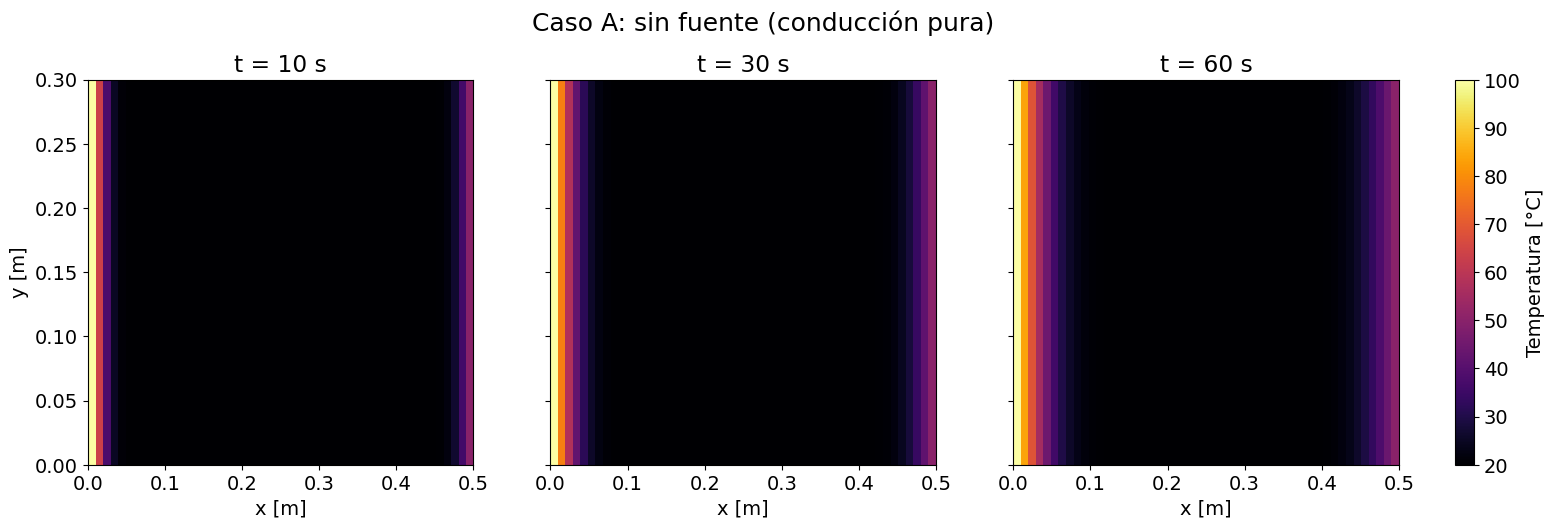

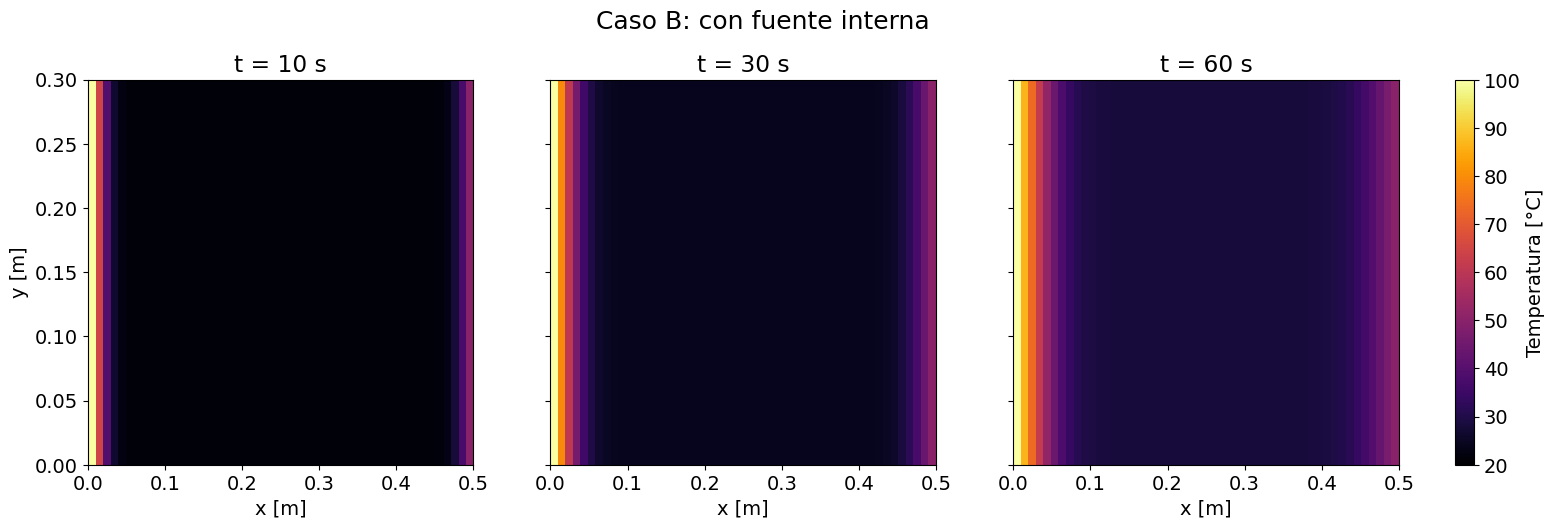

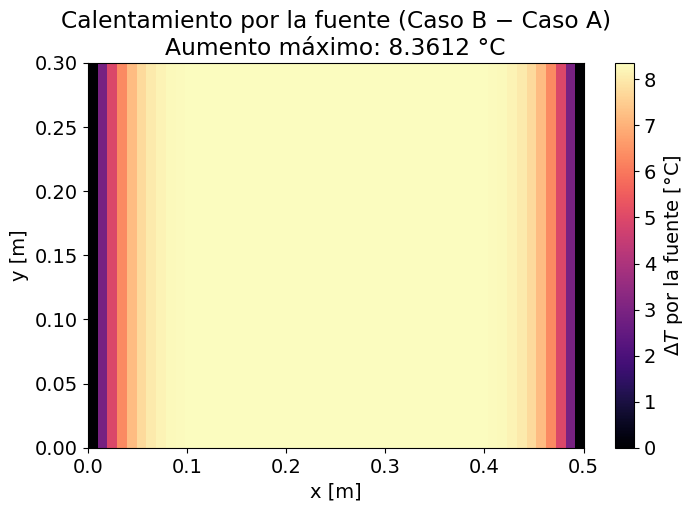

Aumento maximo simulado       : 8.3612 C
Cota adiabatica q*t/(rho*cp)  : 8.3612 C
Longitud de difusion en 60 s  : 0.0274 m

Ambos valores coinciden. La diferencia B - A obedece la misma ecuacion del calor
con la fuente como termino unico y condiciones nulas en los bordes de Dirichlet,
de modo que crece como q*t/(rho*cp) mientras la difusion no alcance el centro.
En 60 s el calor solo penetra unos 2.7 cm desde los bordes, muy lejos de los 25 cm
que los separan del centro: alli el calentamiento es todavia puramente adiabatico.


In [4]:
q_fuente = 5e5   # W/m^3
tiempos_snap = [10.0, 30.0, 60.0]

dt_ref = paso_estable(0.01, 0.01)
Nx, Ny = malla(0.01, 0.01)
Fo = alpha * dt_ref * (1 / 0.01**2 + 1 / 0.01**2)
print(f"Malla: {Nx} x {Ny} nodos     dt = {dt_ref:.4f} s")
print(f"Fo = alpha*dt*(1/dx^2 + 1/dy^2) = {Fo:.4f}   (limite de estabilidad: 0.5)")

caso_A = solver_ftcs(60.0, q0=0.0,      tiempos=tiempos_snap)
caso_B = solver_ftcs(60.0, q0=q_fuente, tiempos=tiempos_snap)


def mapa_temperaturas(resultado, titulo, archivo):
    plt.rcParams.update({"font.size": 14})
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    im = None
    for ax, t in zip(axes, tiempos_snap):
        im = ax.imshow(resultado["snapshots"][t], origin="lower",
                       extent=[0, Lx, 0, Ly], cmap="inferno",
                       vmin=20, vmax=100, aspect="auto")
        ax.set_title(f"t = {t:.0f} s")
        ax.set_xlabel("x [m]")
    axes[0].set_ylabel("y [m]")
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
    cbar.set_label("Temperatura [°C]")
    plt.suptitle(titulo, fontsize=18, y=1.02)
    plt.savefig(archivo, bbox_inches="tight", dpi=300)
    plt.show()


mapa_temperaturas(caso_A, "Caso A: sin fuente (conducción pura)", "casoA_combinado.png")
mapa_temperaturas(caso_B, "Caso B: con fuente interna", "casoB_combinado.png")

diferencia = caso_B["snapshots"][60.0] - caso_A["snapshots"][60.0]
max_dif = diferencia.max()
dif_teorica = q_fuente * 60.0 / (rho * cp)

plt.figure(figsize=(8, 5))
plt.imshow(diferencia, origin="lower", extent=[0, Lx, 0, Ly], cmap="magma", aspect="auto")
plt.colorbar(label=r"$\Delta T$ por la fuente [°C]")
plt.title(f"Calentamiento por la fuente (Caso B − Caso A)\nAumento máximo: {max_dif:.4f} °C")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.savefig("diferencia.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"Aumento maximo simulado       : {max_dif:.4f} C")
print(f"Cota adiabatica q*t/(rho*cp)  : {dif_teorica:.4f} C")
print(f"Longitud de difusion en 60 s  : {np.sqrt(alpha*60):.4f} m")
print()
print("Ambos valores coinciden. La diferencia B - A obedece la misma ecuacion del calor")
print("con la fuente como termino unico y condiciones nulas en los bordes de Dirichlet,")
print("de modo que crece como q*t/(rho*cp) mientras la difusion no alcance el centro.")
print("En 60 s el calor solo penetra unos 2.7 cm desde los bordes, muy lejos de los 25 cm")
print("que los separan del centro: alli el calentamiento es todavia puramente adiabatico.")

## Parte 3 — Verificación: numérico frente a analítico

Se contrasta el solver contra la solución exacta en los mismos puntos de la Parte 1, y se
reportan además las normas de error $L_2$ y $L_\infty$ sobre toda la malla.

In [5]:
filas = []
for t in tiempos:
    t0 = time.perf_counter()
    res = solver_ftcs(t, q0=0.0)
    transcurrido = time.perf_counter() - t0

    xs = np.linspace(0, Lx, res["T"].shape[1])
    perfil_ana = T_analitica(xs, t)
    T_ana_mat = np.tile(perfil_ana, (res["T"].shape[0], 1))

    dif = res["T"] - T_ana_mat
    L2   = np.linalg.norm(dif.ravel()) / np.sqrt(dif.size)
    Linf = np.abs(dif).max()

    for xp, yp in puntos:
        ix, iy = int(round(xp / 0.01)), int(round(yp / 0.01))
        v_num = res["T"][iy, ix]
        v_ana = float(T_analitica(xp, t))
        filas.append({"t [s]": t, "punto": f"({xp}, {yp})",
                      "T analitica [C]": v_ana, "T numerica [C]": v_num,
                      "error [%]": abs((v_num - v_ana) / v_ana) * 100,
                      "L2 [C]": L2, "Linf [C]": Linf,
                      "CPU [s]": transcurrido})

df_ver = pd.DataFrame(filas)
display(df_ver.style.format({
    "T analitica [C]": "{:.4f}", "T numerica [C]": "{:.4f}",
    "error [%]": "{:.4f}", "L2 [C]": "{:.4f}", "Linf [C]": "{:.4f}",
    "CPU [s]": "{:.3f}"}).hide(axis="index"))

t [s],punto,T analitica [C],T numerica [C],error [%],L2 [C],Linf [C],CPU [s]
5.000000,"(0.25, 0.15)",19.9986,20.0000,0.0069,0.5308,3.1530,0.000
5.000000,"(0.4, 0.05)",20.0014,20.0000,0.0068,0.5308,3.1530,0.000
20.000000,"(0.25, 0.15)",20.0000,20.0000,0.0000,0.1992,0.8606,0.000
20.000000,"(0.4, 0.05)",20.0002,20.0001,0.0008,0.1992,0.8606,0.000


## Parte 4 — Estudio de convergencia

Se refina la malla y se mide el error global frente a la solución analítica. Como el paso
temporal estable escala con $\Delta x^2$, refinar el espacio encarece el cálculo rápidamente:
el gráfico muestra ese compromiso entre precisión y costo.

dx [m],dt [s],nodos,L2 [C],Linf [C],CPU [s]
0.020000,7.1760,26x16,0.74333,3.15145,0.000
0.010000,1.7940,51x31,0.19918,0.86062,0.000
0.005000,0.4485,101x61,0.05050,0.21824,0.003


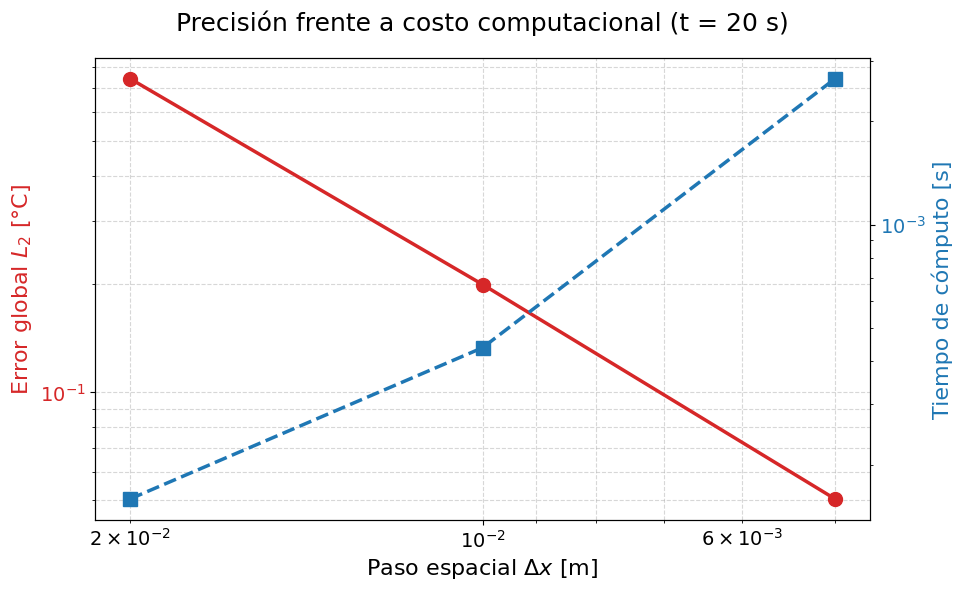

Orden de convergencia observado: 1.940
El esquema es formalmente de segundo orden en el espacio, y el valor medido lo
confirma. La pequena diferencia respecto de 2 proviene de que el error total
incluye tambien la contribucion temporal y el truncamiento de la serie analitica
empleada como referencia.


In [6]:
t_conv = 20.0
resultados = []

for dx_t in [0.02, 0.01, 0.005]:
    t0 = time.perf_counter()
    res = solver_ftcs(t_conv, dx=dx_t, dy=dx_t, q0=0.0)
    transcurrido = time.perf_counter() - t0

    xs = np.linspace(0, Lx, res["T"].shape[1])
    T_ana_mat = np.tile(T_analitica(xs, t_conv), (res["T"].shape[0], 1))
    dif = res["T"] - T_ana_mat

    resultados.append({"dx [m]": dx_t, "dt [s]": res["dt"],
                       "nodos": f'{res["T"].shape[1]}x{res["T"].shape[0]}',
                       "L2 [C]": np.linalg.norm(dif.ravel()) / np.sqrt(dif.size),
                       "Linf [C]": np.abs(dif).max(),
                       "CPU [s]": transcurrido})

df_conv = pd.DataFrame(resultados)
display(df_conv.style.format({
    "dt [s]": "{:.4f}", "L2 [C]": "{:.5f}",
    "Linf [C]": "{:.5f}", "CPU [s]": "{:.3f}"}).hide(axis="index"))

plt.rcParams.update({"font.size": 14})
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.loglog(df_conv["dx [m]"], df_conv["L2 [C]"], "o-", color="tab:red",
           lw=2.5, ms=10, label="Error $L_2$")
ax1.set_xlabel(r"Paso espacial $\Delta x$ [m]", fontsize=16)
ax1.set_ylabel(r"Error global $L_2$ [°C]", color="tab:red", fontsize=16)
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.invert_xaxis()
ax1.grid(True, which="both", ls="--", alpha=0.5)

ax2 = ax1.twinx()
ax2.loglog(df_conv["dx [m]"], df_conv["CPU [s]"], "s--", color="tab:blue",
           lw=2.5, ms=10, label="Tiempo CPU")
ax2.set_ylabel("Tiempo de cómputo [s]", color="tab:blue", fontsize=16)
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title(f"Precisión frente a costo computacional (t = {t_conv:.0f} s)", fontsize=18, pad=20)
plt.savefig("convergencia.png", bbox_inches="tight", dpi=300)
plt.show()

orden = np.polyfit(np.log(df_conv["dx [m]"]), np.log(df_conv["L2 [C]"]), 1)[0]
print(f"Orden de convergencia observado: {orden:.3f}")
print("El esquema es formalmente de segundo orden en el espacio, y el valor medido lo")
print("confirma. La pequena diferencia respecto de 2 proviene de que el error total")
print("incluye tambien la contribucion temporal y el truncamiento de la serie analitica")
print("empleada como referencia.")

## Parte 5 — Sensibilidad a la difusividad térmica

Se repite la simulación con $\alpha$ variada en $\pm 50\%$, registrando la temperatura en una
sonda situada cerca del borde caliente. El paso temporal se fija con la difusividad más alta,
de modo que las tres corridas sean estables y comparables.

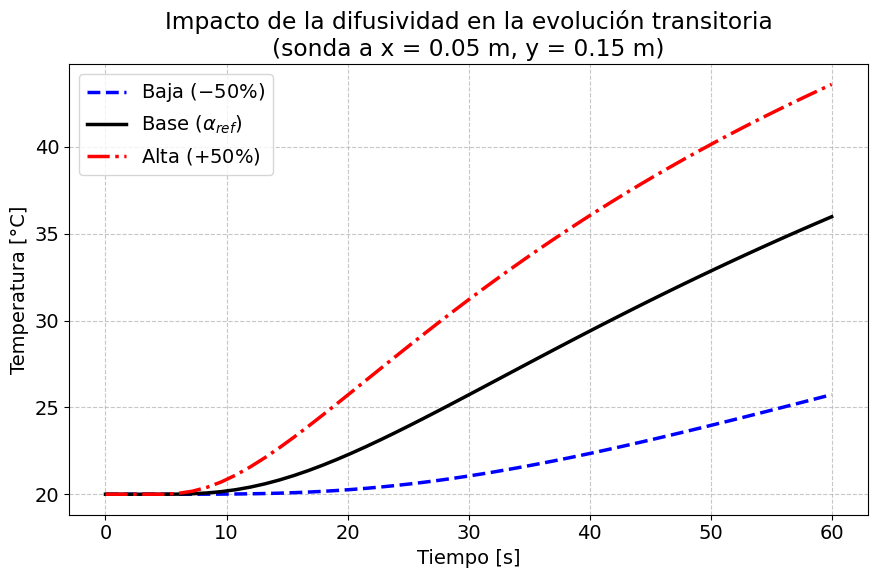

In [7]:
alphas   = [0.5 * alpha, alpha, 1.5 * alpha]
etiquetas = [r"Baja ($-50\%$)", r"Base ($\alpha_{ref}$)", r"Alta ($+50\%$)"]
colores  = ["blue", "black", "red"]
estilos  = ["--", "-", "-."]

dx = dy = 0.01
Nx, Ny = malla(dx, dy)
sonda = (Ny // 2, int(round(0.05 / dx)))      # (fila, columna) -> y = Ly/2, x = 0.05 m
dt_comun = paso_estable(dx, dy, max(alphas))

plt.figure(figsize=(9, 6))
for a_val, etiqueta, color, estilo in zip(alphas, etiquetas, colores, estilos):
    res = solver_ftcs(60.0, dx=dx, dy=dy, alpha_val=a_val, dt=dt_comun, sonda=sonda)
    plt.plot(res["t_sonda"], res["T_sonda"], label=etiqueta,
             color=color, linestyle=estilo, lw=2.5)

plt.title("Impacto de la difusividad en la evolución transitoria\n"
          "(sonda a x = 0.05 m, y = 0.15 m)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Temperatura [°C]")
plt.legend()
plt.grid(True, ls="--", alpha=0.7)
plt.tight_layout()
plt.savefig("parametrico_alpha.png", dpi=300)
plt.show()

## Parte 6 — Sensibilidad a la intensidad de la fuente

Perfil de temperatura a media altura tras 60 s, para tres intensidades de fuente, contrastado
con la solución analítica sin generación interna.

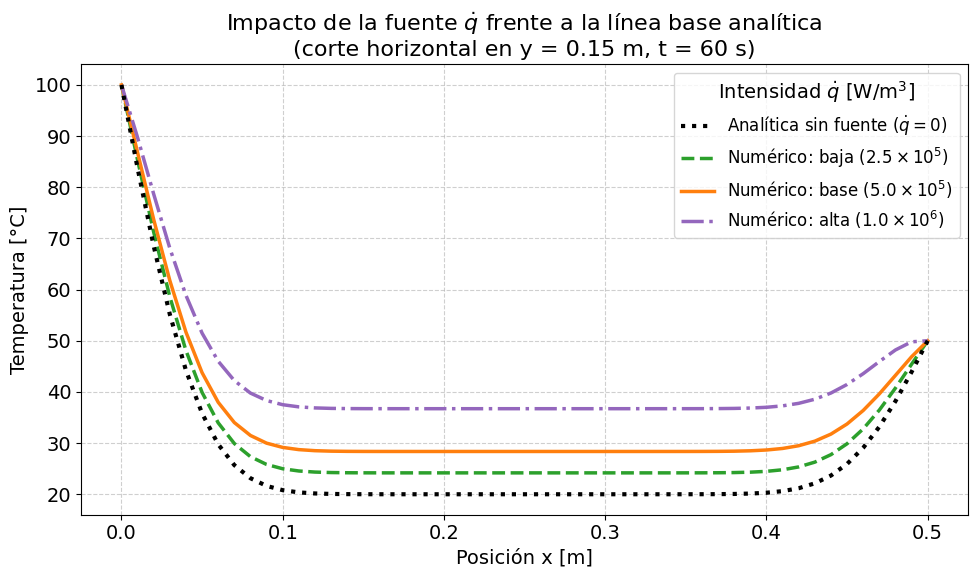

In [8]:
q_valores  = [2.5e5, 5.0e5, 1.0e6]
etiquetas_q = [r"Numérico: baja ($2.5\times 10^5$)",
               r"Numérico: base ($5.0\times 10^5$)",
               r"Numérico: alta ($1.0\times 10^6$)"]
colores_q  = ["tab:green", "tab:orange", "tab:purple"]
estilos_q  = ["--", "-", "-."]

t_final = 60.0
dx = dy = 0.01
Nx, Ny = malla(dx, dy)
x_eje = np.linspace(0, Lx, Nx)

plt.rcParams.update({"font.size": 14, "lines.linewidth": 2.5})
plt.figure(figsize=(10, 6))

plt.plot(x_eje, T_analitica(x_eje, t_final, n_terminos=200), "k:",
         label=r"Analítica sin fuente ($\dot{q}=0$)", lw=3, zorder=10)

for q0, etiqueta, color, estilo in zip(q_valores, etiquetas_q, colores_q, estilos_q):
    res = solver_ftcs(t_final, dx=dx, dy=dy, q0=q0)
    plt.plot(x_eje, res["T"][Ny // 2, :], label=etiqueta,
             linestyle=estilo, color=color, lw=2.5)

plt.title(r"Impacto de la fuente $\dot{q}$ frente a la línea base analítica"
          f"\n(corte horizontal en y = {Ly/2} m, t = {t_final:.0f} s)", fontsize=16)
plt.xlabel("Posición x [m]", fontsize=14)
plt.ylabel("Temperatura [°C]", fontsize=14)
plt.legend(title=r"Intensidad $\dot{q}$ [W/m$^3$]", fontsize=12)
plt.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.savefig("parametrico_q0.png", dpi=300)
plt.show()